# Financial Credibility & Loan Decision Analysis

## Business Understanding

Analisis ini bertujuan untuk memahami karakteristik finansial dan demografis nasabah serta mengidentifikasi pola yang berkaitan dengan credit_score. Analisis dilakukan untuk mengetahui apakah terdapat perbedaan karakteristik antar kelompok credit score dan apakah terdapat hubungan statistik antara variabel tertentu dengan credit score.

### Tools
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, chi2_contingency, kruskal

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("/content/credit_score_data.csv")
df.head()

,income_stability,average_eligible_emi,average_usable_salary,average_monthly_credit,employer_category,employment_tenure_years,average_month_end_balance,bounce_count,gambling_transaction_count,active_loans_count,has_credit_card,has_personal_loan,has_home_loan,credit_exposure_intensity,average_obligation_to_income_ratio,credit_score
0,STABLE,50390.18,141932,363258.21,Category B (Private Ltd),2.95,7285.71,0,0,2,1,1,0,3,14.79,681
1,FLUCTUATING,78874.08,262709,784034.81,Category B (Private Ltd),4.73,3172.37,0,0,3,1,1,0,4,41.14,593
2,STABLE,35176.42,77435,169182.24,Category A (MNC/Govt/PSU),4.68,1227.70,1,0,1,0,1,0,2,35.89,599
3,STABLE,113193.83,261995,325941.81,Category B (Private Ltd),0.17,377834.49,0,0,5,1,1,1,6,56.47,711
4,STABLE,123516.80,212283,592196.27,Category B (Private Ltd),12.75,5867.17,0,0,4,1,1,1,5,55.87,663


### Data Understanding

Pada tahap Data Understanding, dilakukan pemeriksaan terhadap ukuran dataset, nama kolom, tipe data, dan statistik deskriptif. Tahap ini bertujuan untuk memahami struktur data sebelum dilakukan proses pembersihan dan analisis lebih lanjut.

In [ ]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nSummary Statistics:")
display(df.describe(include='all').T)

Shape: (10000, 16)

Columns:
['income_stability', 'average_eligible_emi', 'average_usable_salary', 'average_monthly_credit', 'employer_category', 'employment_tenure_years', 'average_month_end_balance', 'bounce_count', 'gambling_transaction_count', 'active_loans_count', 'has_credit_card', 'has_personal_loan', 'has_home_loan', 'credit_exposure_intensity', 'average_obligation_to_income_ratio', 'credit_score']

Data Types:
income_stability                       object
average_eligible_emi                  float64
average_usable_salary                   int64
average_monthly_credit                float64
employer_category                      object
employment_tenure_years               float64
average_month_end_balance             float64
bounce_count                            int64
gambling_transaction_count              int64
active_loans_count                      int64
has_credit_card                         int64
has_personal_loan                       int64
has_home_loan            

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
income_stability,10000,3,STABLE,7086,NaN,NaN,NaN,NaN,NaN,NaN,NaN
average_eligible_emi,10000.0,NaN,NaN,NaN,69958.89221,40692.100685,3113.02,36148.5375,66928.97,99725.1575,178975.84
average_usable_salary,10000.0,NaN,NaN,NaN,156581.812,83809.550274,10008.0,84690.25,156563.5,228378.25,299981.0
average_monthly_credit,10000.0,NaN,NaN,NaN,310146.899268,195714.771546,11245.12,150900.6325,283627.835,437815.83,895750.62
employer_category,10000,4,Category A (MNC/Govt/PSU),3975,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_tenure_years,10000.0,NaN,NaN,NaN,5.164282,5.091868,0.0,1.46,3.58,7.2625,43.79
average_month_end_balance,10000.0,NaN,NaN,NaN,334225.844174,338814.404291,179.84,43315.1125,223598.095,530848.3075,1471884.12
bounce_count,10000.0,NaN,NaN,NaN,0.2231,0.600968,0.0,0.0,0.0,0.0,3.0
gambling_transaction_count,10000.0,NaN,NaN,NaN,0.0291,0.217389,0.0,0.0,0.0,0.0,2.0
active_loans_count,10000.0,NaN,NaN,NaN,2.4482,1.698707,0.0,1.0,2.0,4.0,5.0


### Data Quality

Pemeriksaan kualitas data dilakukan untuk memastikan dataset tidak memiliki missing value atau data duplikat yang dapat memengaruhi hasil analisis.

In [ ]:
print("Missing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
0

Duplicate rows:
0


### Data Cleaning

Dataset disalin ke dalam df_clean agar data asli tetap terjaga. Selanjutnya, variabel dikelompokkan menjadi variabel numerik dan kategorikal. Pemisahan ini diperlukan karena masing-masing tipe data membutuhkan metode analisis yang berbeda.

In [ ]:
df_clean = df.copy()

In [ ]:
numeric_columns = df_clean.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = df_clean.select_dtypes(
    include='object'
).columns.tolist()

print("Numeric columns:", numeric_columns)
print("Categorical columns:", categorical_columns)

Numeric columns: ['average_eligible_emi', 'average_usable_salary', 'average_monthly_credit', 'employment_tenure_years', 'average_month_end_balance', 'bounce_count', 'gambling_transaction_count', 'active_loans_count', 'has_credit_card', 'has_personal_loan', 'has_home_loan', 'credit_exposure_intensity', 'average_obligation_to_income_ratio', 'credit_score']
Categorical columns: ['income_stability', 'employer_category']


In [ ]:
for col in categorical_columns:
    print(f"\n{col}:")
    print(df_clean[col].value_counts())


income_stability:
income_stability
STABLE         7086
FLUCTUATING    1948
UNSTABLE        966
Name: count, dtype: int64

employer_category:
employer_category
Category A (MNC/Govt/PSU)                  3975
Category B (Private Ltd)                   3022
Category C (Partnership/Proprietorship)    2011
Unlisted                                    992
Name: count, dtype: int64


### Exploratory Data Analysis

### 1.   Distribusi Credit Score

Analisis ini digunakan untuk mengetahui distribusi pelanggan berdasarkan credit score. Distribusi tersebut penting karena dapat menunjukkan kelompok credit score mana yang paling banyak terdapat dalam dataset.

In [ ]:
credit_summary = (
    df_clean['credit_score']
    .value_counts()
    .rename_axis('credit_score')
    .reset_index(name='customer_count')
)

credit_summary['percentage'] = (
    credit_summary['customer_count']
    / credit_summary['customer_count'].sum()
    * 100
).round(2)

credit_summary

,credit_score,customer_count,percentage
0,681,69,0.69
1,685,64,0.64
2,698,64,0.64
3,656,63,0.63
4,653,63,0.63
...,...,...,...
439,477,1,0.01
440,430,1,0.01
441,486,1,0.01
442,870,1,0.01


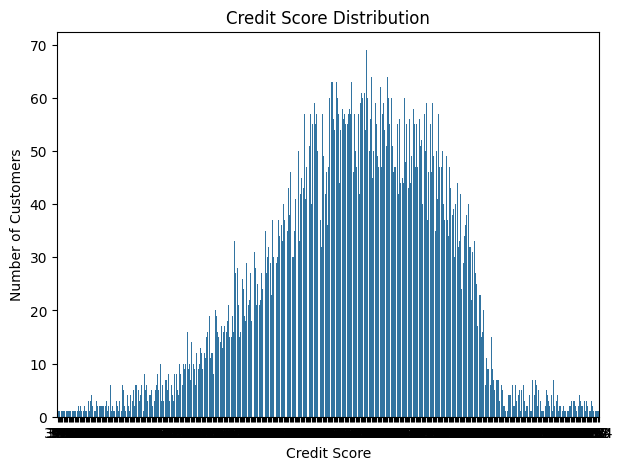

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_clean,
    x='credit_score'
)

plt.title('Credit Score Distribution')
plt.xlabel('Credit Score')
plt.ylabel('Number of Customers')

plt.show()

In [ ]:
numeric_features = [
    col for col in numeric_columns
    if col != 'credit_score'
]

print(numeric_features)

['average_eligible_emi', 'average_usable_salary', 'average_monthly_credit', 'employment_tenure_years', 'average_month_end_balance', 'bounce_count', 'gambling_transaction_count', 'active_loans_count', 'has_credit_card', 'has_personal_loan', 'has_home_loan', 'credit_exposure_intensity', 'average_obligation_to_income_ratio']


In [ ]:
numeric_summary = (
    df_clean
    .groupby('credit_score')[numeric_features]
    .agg(['mean', 'median'])
)

numeric_summary

average_eligible_emi            average_usable_salary            \
                             mean     median                  mean    median   
credit_score                                                                   
359                      16136.23   16136.23               40916.0   40916.0   
374                     118596.21  118596.21              271231.0  271231.0   
381                      43345.56   43345.56               77359.0   77359.0   
388                       8667.50    8667.50               19012.0   19012.0   
390                       9958.37    9958.37               24072.0   24072.0   
...                           ...        ...                   ...       ...   
886                      57319.92   57319.92              284610.0  284610.0   
887                      73183.24   73183.24              211058.0  211058.0   
891                      65218.65   65218.65              285271.0  285271.0   
893                       9820.96    9820.96              202797.0  202797.0   
894                     100882.63  100882.63              196588.0  196588.0   

             average_monthly_credit            employment_tenure_years         \
                               mean     median                    mean median   
credit_score                                                                    
359                        57452.87   57452.87                    2.93   2.93   
374                       580256.02  580256.02                    8.99   8.99   
381                       144215.16  144215.16                    3.01   3.01   
388                        39165.65   39165.65                    1.95   1.95   
390                        53568.26   53568.26                    5.30   5.30   
...                             ...        ...                     ...    ...   
886                       276203.88  276203.88                   15.15  15.15   
887                       321804.35  321804.35                   14.28  14.28   
891                       305863.57  305863.57                   18.72  18.72   
893                        61492.11   61492.11                   10.62  10.62   
894                       375313.22  375313.22                   17.13  17.13   

             average_month_end_balance              ... has_credit_card  \
                                  mean      median  ...            mean   
credit_score                                        ...                   
359                            1140.68     1140.68  ...             1.0   
374                            3002.09     3002.09  ...             1.0   
381                            3484.95     3484.95  ...             0.0   
388                             583.75      583.75  ...             0.0   
390                             470.11      470.11  ...             0.0   
...                                ...         ...  ...             ...   
886                         1399716.79  1399716.79  ...             0.0   
887                          672984.88   672984.88  ...             0.0   
891                          869039.43   869039.43  ...             0.0   
893                          660003.44   660003.44  ...             1.0   
894                          949151.83   949151.83  ...             0.0   

                    has_personal_loan        has_home_loan         \
             median              mean median          mean median   
credit_score                                                        
359             1.0               1.0    1.0           1.0    1.0   
374             1.0               1.0    1.0           1.0    1.0   
381             0.0               0.0    0.0           1.0    1.0   
388             0.0               1.0    1.0           0.0    0.0   
390             0.0               1.0    1.0           0.0    0.0   
...             ...               ...    ...           ...    ...   
886             0.0               0.0    0.0           0.0    0.0   
887             

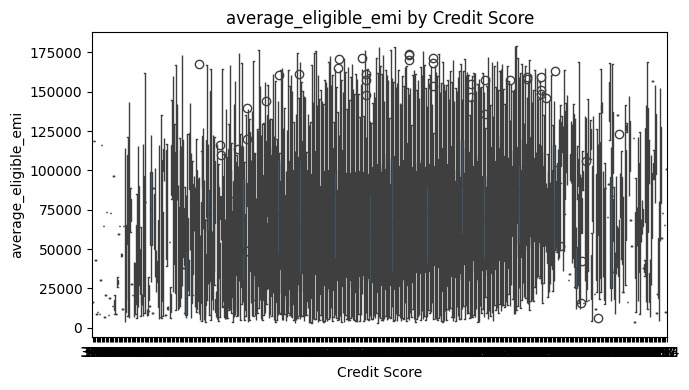

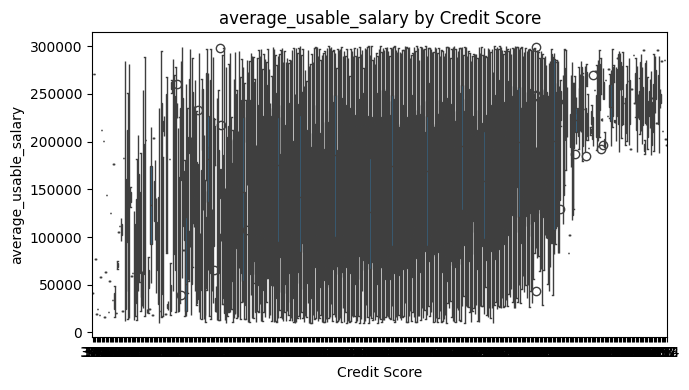

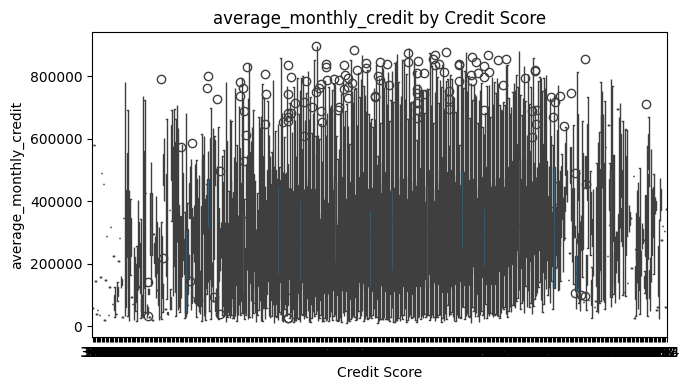

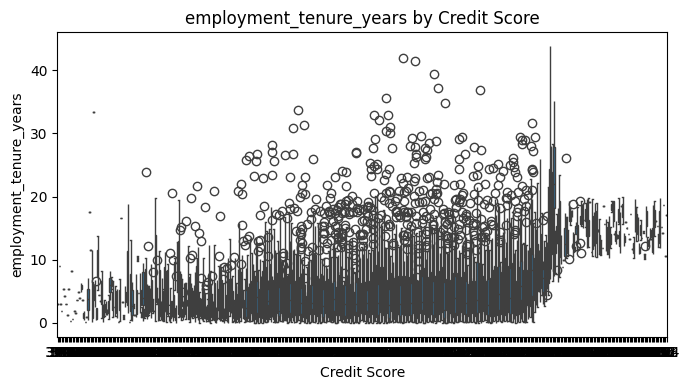

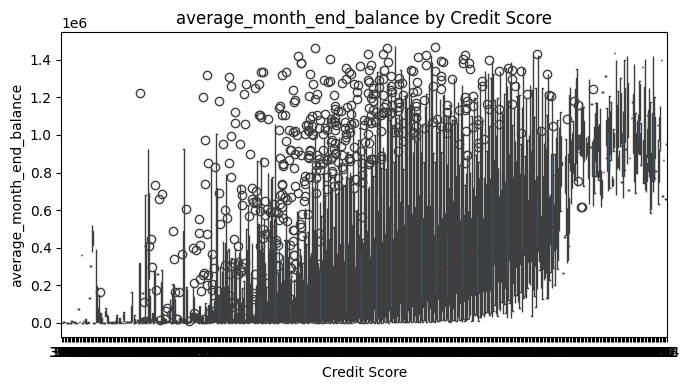

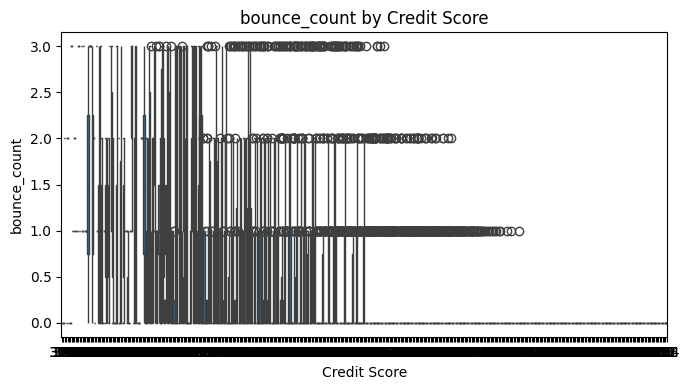

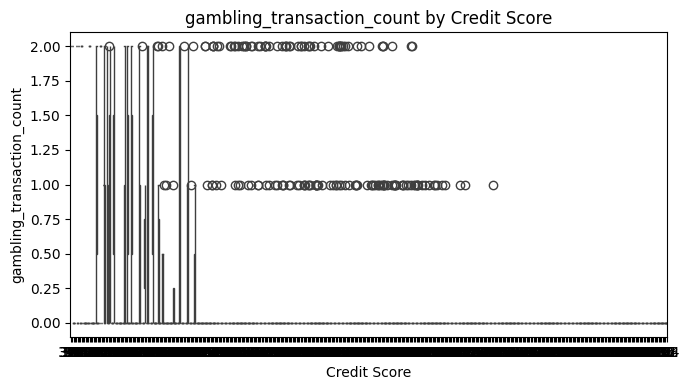

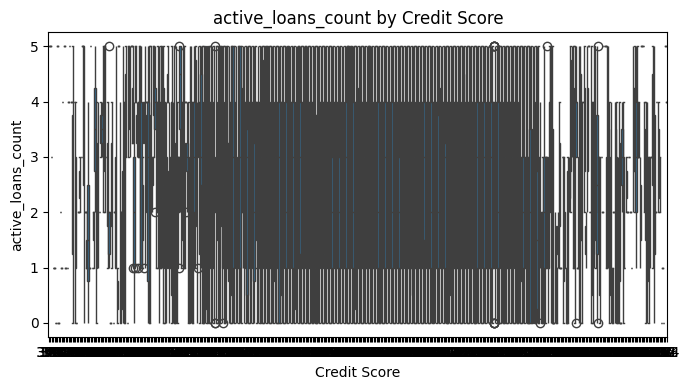

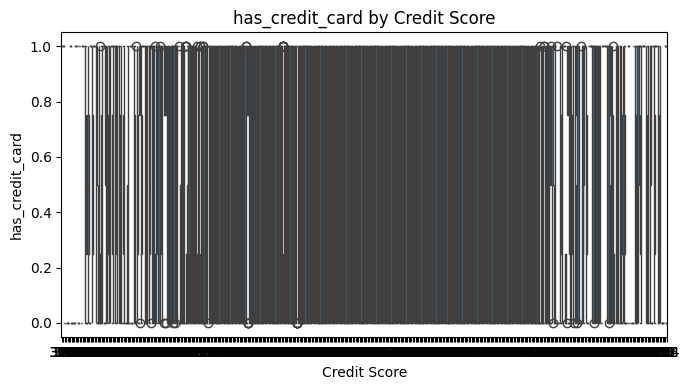

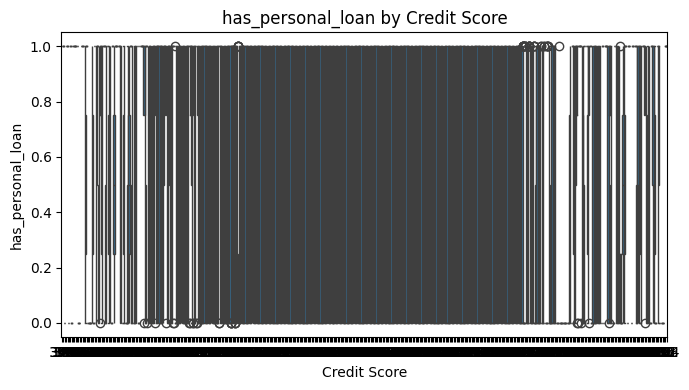

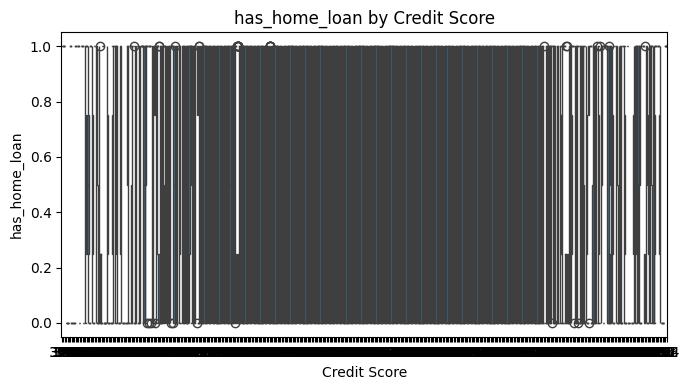

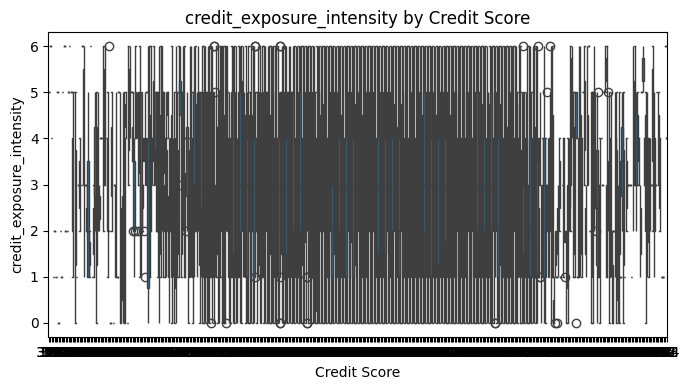

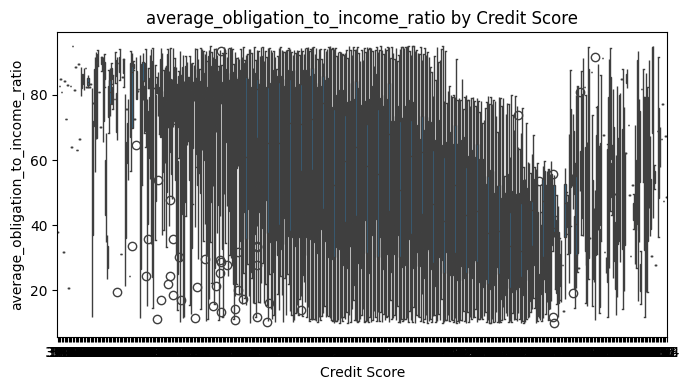

In [ ]:
for col in numeric_features:

    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=df_clean,
        x='credit_score',
        y=col
    )

    plt.title(f'{col} by Credit Score')
    plt.xlabel('Credit Score')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

In [ ]:
print(categorical_columns)

['income_stability', 'employer_category']


In [ ]:
category_features = [
    'income_stability',
    'employer_category'
]

In [ ]:
for col in category_features:

    table = pd.crosstab(
        df_clean[col],
        df_clean['credit_score'],
        normalize='index'
    ) * 100

    print(f"\n{col}")
    display(table.round(2))


income_stability


credit_score,359,374,381,388,390,394,403,407,412,414,...,873,875,876,878,883,886,887,891,893,894
income_stability,,,,,,,,,,,,,,,,,,,,,
FLUCTUATING,0.0,0.05,0.05,0.0,0.00,0.0,0.05,0.0,0.05,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
STABLE,0.0,0.00,0.00,0.0,0.01,0.0,0.00,0.0,0.00,0.0,...,0.03,0.01,0.01,0.04,0.03,0.01,0.01,0.01,0.01,0.01
UNSTABLE,0.1,0.00,0.00,0.1,0.00,0.1,0.00,0.1,0.00,0.1,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00



employer_category


credit_score,359,374,381,388,390,394,403,407,412,414,...,873,875,876,878,883,886,887,891,893,894
employer_category,,,,,,,,,,,,,,,,,,,,,
Category A (MNC/Govt/PSU),0.0,0.00,0.0,0.00,0.00,0.00,0.03,0.00,0.00,0.03,...,0.03,0.00,0.03,0.05,0.03,0.00,0.00,0.00,0.00,0.00
Category B (Private Ltd),0.0,0.00,0.0,0.00,0.03,0.00,0.00,0.03,0.03,0.00,...,0.03,0.03,0.00,0.03,0.03,0.00,0.00,0.03,0.00,0.03
Category C (Partnership/Proprietorship),0.0,0.05,0.0,0.05,0.00,0.05,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.05,0.05,0.00,0.05,0.00
Unlisted,0.1,0.00,0.1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


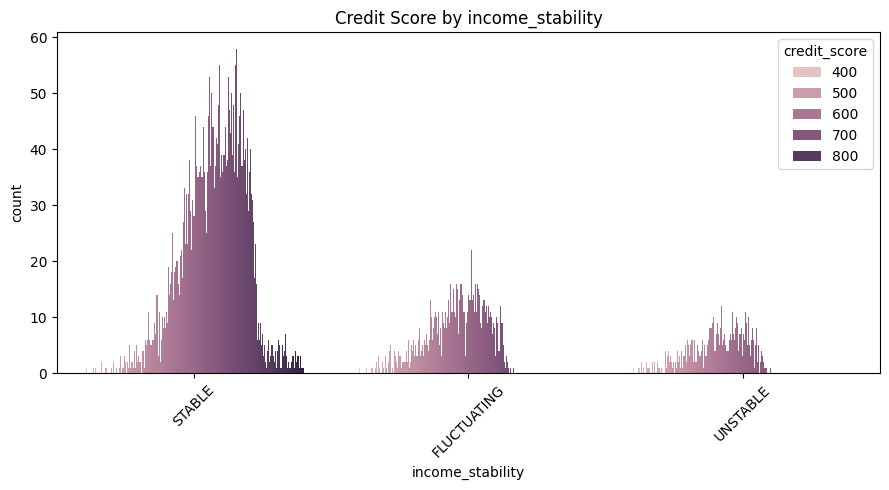

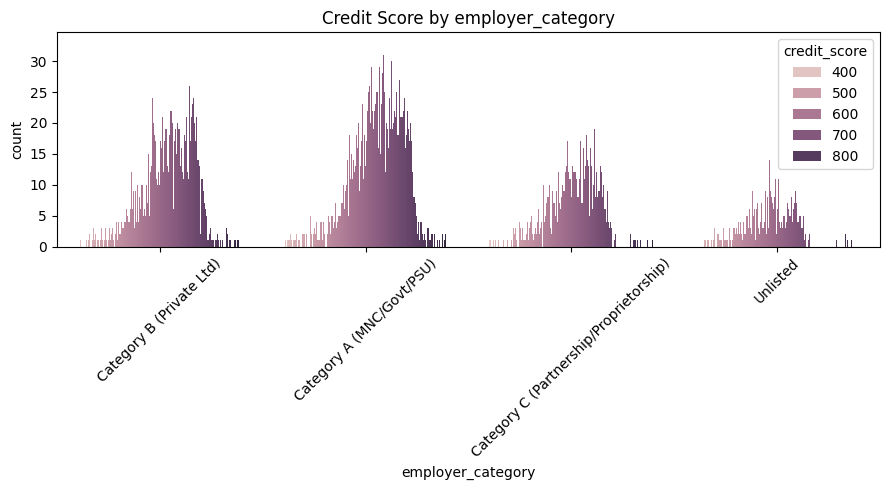

In [ ]:
for col in category_features:

    plt.figure(figsize=(9, 5))

    sns.countplot(
        data=df_clean,
        x=col,
        hue='credit_score'
    )

    plt.title(f'Credit Score by {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

In [ ]:
chi_results = []

for col in category_features:

    table = pd.crosstab(
        df_clean[col],
        df_clean['credit_score']
    )

    chi2, p_value, dof, expected = chi2_contingency(table)

    chi_results.append({
        'Variable': col,
        'Chi2': chi2,
        'p_value': p_value,
        'Significant': p_value < 0.05
    })

chi_results = pd.DataFrame(chi_results)

chi_results.sort_values('p_value')

,Variable,Chi2,p_value,Significant
0,income_stability,3565.381490,0.000000e+00,True
1,employer_category,2092.830181,4.062907e-37,True


In [ ]:
df_clean['credit_score'].nunique()

444

In [ ]:
groups = df_clean['credit_score'].unique()

ttest_results = []

for col in numeric_features:

    group1 = df_clean.loc[
        df_clean['credit_score'] == groups[0], col
    ].dropna()

    group2 = df_clean.loc[
        df_clean['credit_score'] == groups[1], col
    ].dropna()

    statistic, p_value = ttest_ind(
        group1,
        group2,
        equal_var=False
    )

    ttest_results.append({
        'Variable': col,
        't_statistic': statistic,
        'p_value': p_value,
        'Significant': p_value < 0.05
    })

ttest_results = pd.DataFrame(ttest_results)

ttest_results.sort_values('p_value')

,Variable,t_statistic,p_value,Significant
4,average_month_end_balance,3.844646,0.000297,True
0,average_eligible_emi,2.404623,0.020595,True
1,average_usable_salary,1.864732,0.070512,False
12,average_obligation_to_income_ratio,-1.600780,0.117618,False
5,bounce_count,-1.380451,0.180846,False
6,gambling_transaction_count,1.349603,0.181619,False
3,employment_tenure_years,-0.828952,0.414830,False
2,average_monthly_credit,0.749716,0.459217,False
11,credit_exposure_intensity,0.606512,0.548757,False
8,has_credit_card,0.508669,0.614375,False


In [ ]:
kruskal_results = []

for col in numeric_features:

    groups_data = [
        group[col].dropna()
        for _, group in df_clean.groupby('credit_score')
    ]

    statistic, p_value = kruskal(*groups_data)

    kruskal_results.append({
        'Variable': col,
        'H_statistic': statistic,
        'p_value': p_value,
        'Significant': p_value < 0.05
    })

kruskal_results = pd.DataFrame(kruskal_results)

kruskal_results.sort_values('p_value')

,Variable,H_statistic,p_value,Significant
4,average_month_end_balance,2874.469029,0.000000e+00,True
12,average_obligation_to_income_ratio,1725.331045,1.994005e-150,True
6,gambling_transaction_count,1507.254633,5.447824e-116,True
5,bounce_count,1497.529827,1.695282e-114,True
3,employment_tenure_years,1146.705687,8.081932e-64,True
1,average_usable_salary,835.394149,1.946916e-26,True
0,average_eligible_emi,713.630485,5.410229e-15,True
2,average_monthly_credit,677.576583,4.317157e-12,True
9,has_personal_loan,522.934442,5.216550e-03,True
11,credit_exposure_intensity,498.815049,3.408438e-02,True


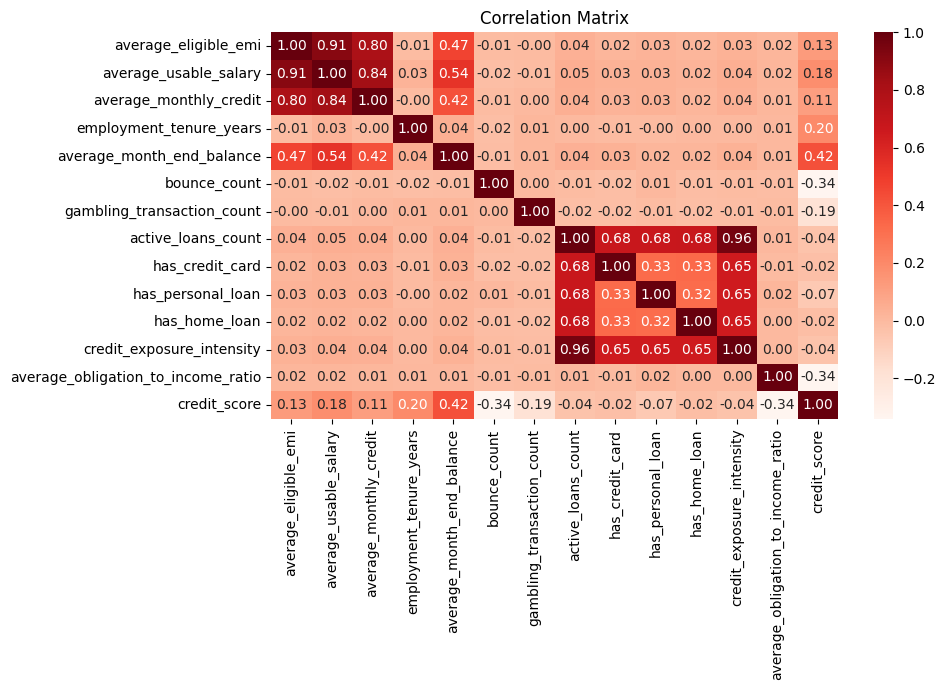

In [ ]:
correlation = df_clean[numeric_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='Reds'
)

plt.title('Correlation Matrix')
plt.tight_layout()

plt.show()

In [ ]:
correlation['credit_score'].sort_values(
    ascending=False
)

,credit_score
credit_score,1.000000
average_month_end_balance,0.420313
employment_tenure_years,0.196834
average_usable_salary,0.180210
average_eligible_emi,0.128012
average_monthly_credit,0.112013
has_home_loan,-0.017782
has_credit_card,-0.022672
credit_exposure_intensity,-0.038710
active_loans_count,-0.039492


In [ ]:
final_summary = (
    df_clean
    .groupby('credit_score')[numeric_features]
    .mean()
    .round(2)
)

final_summary

,average_eligible_emi,average_usable_salary,average_monthly_credit,employment_tenure_years,average_month_end_balance,bounce_count,gambling_transaction_count,active_loans_count,has_credit_card,has_personal_loan,has_home_loan,credit_exposure_intensity,average_obligation_to_income_ratio
credit_score,,,,,,,,,,,,,
359,16136.23,40916.0,57452.87,2.93,1140.68,0.0,2.0,5.0,1.0,1.0,1.0,5.0,37.95
374,118596.21,271231.0,580256.02,8.99,3002.09,0.0,2.0,5.0,1.0,1.0,1.0,6.0,82.68
381,43345.56,77359.0,144215.16,3.01,3484.95,2.0,0.0,3.0,0.0,0.0,1.0,4.0,84.91
388,8667.50,19012.0,39165.65,1.95,583.75,0.0,0.0,1.0,0.0,1.0,0.0,1.0,80.87
390,9958.37,24072.0,53568.26,5.30,470.11,2.0,2.0,1.0,0.0,1.0,0.0,2.0,31.79
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,57319.92,284610.0,276203.88,15.15,1399716.79,0.0,0.0,0.0,0.0,0.0,0.0,1.0,66.58
887,73183.24,211058.0,321804.35,14.28,672984.88,0.0,0.0,1.0,0.0,0.0,0.0,1.0,77.36
891,65218.65,285271.0,305863.57,18.72,869039.43,0.0,0.0,0.0,0.0,0.0,0.0,1.0,47.41


### KESIMPULAN

Berdasarkan analisis yang telah dilakukan, dapat disimpulkan bahwa **skor kredit nasabah sangat dipengaruhi oleh kombinasi antara stabilitas finansial, perilaku keuangan, dan profil pekerjaan.**

**Faktor-faktor Kunci Pendorong Skor Kredit Positif meliputi:**
*   **Saldo Akhir Bulan Rata-rata (`average_month_end_balance`)** dan **Masa Kerja (`employment_tenure_years`)** menunjukkan korelasi positif yang signifikan, mengindikasikan bahwa nasabah dengan kapasitas finansial dan stabilitas pekerjaan yang lebih baik cenderung memiliki skor kredit lebih tinggi.
*   **Stabilitas Pendapatan (`income_stability`)** dan **Kategori Pekerjaan (`employer_category`)** juga secara statistik memiliki hubungan yang kuat dengan skor kredit, menyoroti pentingnya konsistensi pendapatan dan kredibilitas pemberi kerja.

**Faktor-faktor Kunci Penghambat Skor Kredit Negatif meliputi:**
*   **Rasio Kewajiban terhadap Pendapatan (`average_obligation_to_income_ratio`)**, **Jumlah Transaksi Gagal (`bounce_count`)**, dan **Jumlah Transaksi Perjudian (`gambling_transaction_count`)** menunjukkan korelasi negatif yang substansial. Ini mengindikasikan bahwa tingkat beban finansial yang tinggi serta perilaku keuangan berisiko secara signifikan menurunkan skor kredit.

